# Práctica 2: Detección de Outliers en Datos de Sensores

## Aplicaciones Avanzadas de Inteligencia Artificial

**Objetivo:** Aplicar diferentes técnicas de detección de anomalías/outliers en un dataset de sensores industriales.

### Contenido:
1. Carga y exploración de datos
2. Preprocesamiento
3. Métodos estadísticos (IQR, Z-score)
4. Isolation Forest
5. Local Outlier Factor (LOF)
6. Análisis y comparación de resultados

## 1. Importación de Librerías

In [2]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para detección de outliers
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente ✓")

Librerías importadas correctamente ✓


## 2. Carga y Exploración de Datos

El dataset contiene lecturas de 52 sensores de una máquina industrial con un timestamp y el estado de la máquina (`machine_status`).

In [3]:
# Cargar el dataset
df = pd.read_csv('sensor.csv')

# Información básica del dataset
print("=" * 60)
print("INFORMACIÓN DEL DATASET")
print("=" * 60)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nTipos de datos:\n{df.dtypes}")
df.head()

INFORMACIÓN DEL DATASET
Dimensiones: 220320 filas x 55 columnas

Columnas: ['Unnamed: 0', 'timestamp', 'sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51', 'machine_status']

Tipos de datos:
Unnamed: 0          int64
timestamp          object
sensor_00         float64
sensor_01         float64
sensor_02         float64
sensor_03         float64
sensor_04         float64
sens

,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,37.22740,47.52422,31.11716,1.681353,419.5747,NaN,461.8781,466.3284,2.565284,665.3993,398.9862,880.0001,498.8926,975.9409,627.6740,741.7151,848.0708,429.0377,785.1935,684.9443,594.4445,682.8125,680.4416,433.7037,171.9375,341.9039,195.0655,90.32386,40.36458,31.51042,70.57291,30.98958,31.770832,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,37.86777,48.17723,32.08894,1.708474,420.8480,NaN,462.7798,459.6364,2.500062,666.2234,399.9418,880.4237,501.3617,982.7342,631.1326,740.8031,849.8997,454.2390,778.5734,715.6266,661.5740,721.8750,694.7721,441.2635,169.9820,343.1955,200.9694,93.90508,41.40625,31.25000,69.53125,30.46875,31.770830,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,38.57977,48.65607,31.67221,1.579427,420.7494,NaN,462.8980,460.8858,2.509521,666.0114,399.1046,878.8917,499.0430,977.7520,625.4076,739.2722,847.7579,474.8731,779.5091,690.4011,686.1111,754.6875,683.3831,446.2493,166.4987,343.9586,193.1689,101.04060,41.92708,31.51042,72.13541,30.46875,31.510420,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,39.48939,49.06298,31.95202,1.683831,419.8926,NaN,461.4906,468.2206,2.604785,663.2111,400.5426,882.5874,498.5383,979.5755,627.1830,737.6033,846.9182,408.8159,785.2307,704.6937,631.4814,766.1458,702.4431,433.9081,164.7498,339.9630,193.8770,101.70380,42.70833,31.51042,76.82291,30.98958,31.510420,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [4]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS


,Unnamed: 0,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,220320.000000,210112.000000,219951.000000,220301.000000,220301.000000,220301.000000,220301.000000,215522.000000,214869.000000,215213.000000,215725.000000,220301.000000,220301.000000,220301.000000,220301.000000,220299.000000,0.0,220289.000000,220274.000000,220274.000000,220304.000000,220304.000000,220304.000000,220279.000000,220304.000000,220304.000000,220284.000000,220300.000000,220304.000000,220304.000000,220248.000000,220059.000000,220304.00000,220252.000000,220304.000000,220304.000000,220304.000000,220304.000000,220304.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,220293.000000,143303.000000,204937.000000
mean,110159.500000,2.372221,47.591611,50.867392,43.752481,590.673936,73.396414,13.501537,15.843152,15.200721,14.799210,41.470339,41.918319,29.136975,7.078858,376.860041,NaN,416.472892,421.127517,2.303785,590.829775,360.805165,796.225942,459.792815,922.609264,556.235397,649.144799,786.411781,501.506589,851.690339,576.195305,614.596442,863.32310,804.283915,486.405980,234.971776,427.129817,593.033876,60.787360,49.655946,36.610444,68.844530,35.365126,35.453455,43.879591,42.656877,43.094984,48.018585,44.340903,150.889044,57.119968,183.049260,202.699667
std,63601.049991,0.412227,3.296666,3.666820,2.418887,144.023912,17.298247,2.163736,2.201155,2.037390,2.091963,12.093519,13.056425,10.113935,6.901755,113.206382,NaN,126.072642,129.156175,0.765883,199.345820,101.974118,226.679317,154.528337,291.835280,182.297979,220.865166,246.663608,169.823173,313.074032,225.764091,195.726872,283.54476,260.602361,150.751836,88.376065,141.772519,289.385511,37.604883,10.540397,15.613723,21.371139,7.898665,10.259521,11.044404,11.576355,12.837520,15.641284,10.442437,82.244957,19.143598,65.258650,109.588607
min,0.000000,0.000000,0.000000,33.159720,31.640620,2.798032,0.000000,0.014468,0.000000,0.028935,0.000000,0.000000,0.000000,0.000000,0.000000,32.409550,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,95.527660,0.000000,0.000000,0.000000,0.000000,43.154790,0.000000,4.319347,0.636574,0.000000,23.95833,0.240716,6.460602,54.882370,0.000000,2.260970,0.000000,24.479166,19.270830,23.437500,20.833330,22.135416,24.479166,25.752316,26.331018,26.331018,27.199070,26.331018,26.620370,27.488426,27.777779
25%,55079.750000,2.438831,46.310760,50.390620,42.838539,626.620400,69.976260,13.346350,15.907120,15.183740,15.053530,40.705260,38.856420,28.686810,1.538516,418.103250,NaN,459.453400,454.138825,2.447542,662.768975,398.021500,875.464400,478.962600,950.922400,601.151050,693.957800,790.489575,448.297950,782.682625,518.947225,627.777800,839.06240,760.607475,489.761075,172.486300,353.176625,288.547575,28.799220,45.572910,32.552080,57.812500,32.552080,32.812500,39.583330,36.747684,36.747684,40.509258,39.062500,83.912030,47.743060,167.534700,179.108800
50%,110159.500000,2.456539,48.133678,51.649300,44.227428,632.638916,75.576790,13.642940,16.167530,15.494790,15.082470,44.291340,45.363140,32.515830,2.929809,420.106200,NaN,462.856100,462.020250,2.533704,665.672400,399.367000,879.697600,531.855900,981.925000,625.873500,740.203500,861.869600,494.468450,967.279850,564.872500,668.981400,917.70830,878.850750,512.271750,226.356050,473.349350,709.668050,64.295485,49.479160,35.416660,66.406250,34.895832,35.156250,42.968750,40.509260,40.219910,44.849540,42.534720,138.020800,52.662040,193.865700,197.338000
75%,165239.250000,2.499826,49.479160

In [5]:
# Análisis de valores faltantes
print("VALORES FALTANTES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Porcentaje (%)': missing_pct})
print(missing_df[missing_df['Valores Faltantes'] > 0])
print(f"\nTotal de valores faltantes: {df.isnull().sum().sum()}")

VALORES FALTANTES
           Valores Faltantes  Porcentaje (%)
sensor_00              10208        4.633261
sensor_01                369        0.167484
sensor_02                 19        0.008624
sensor_03                 19        0.008624
sensor_04                 19        0.008624
sensor_05                 19        0.008624
sensor_06               4798        2.177741
sensor_07               5451        2.474129
sensor_08               5107        2.317992
sensor_09               4595        2.085603
sensor_10                 19        0.008624
sensor_11                 19        0.008624
sensor_12                 19        0.008624
sensor_13                 19        0.008624
sensor_14                 21        0.009532
sensor_15             220320      100.000000
sensor_16                 31        0.014070
sensor_17                 46        0.020879
sensor_18                 46        0.020879
sensor_19                 16        0.007262
sensor_20                 16        0

DISTRIBUCIÓN DE MACHINE_STATUS
machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

Porcentaje:
machine_status
NORMAL        93.43
RECOVERING     6.57
BROKEN         0.00
Name: count, dtype: float64


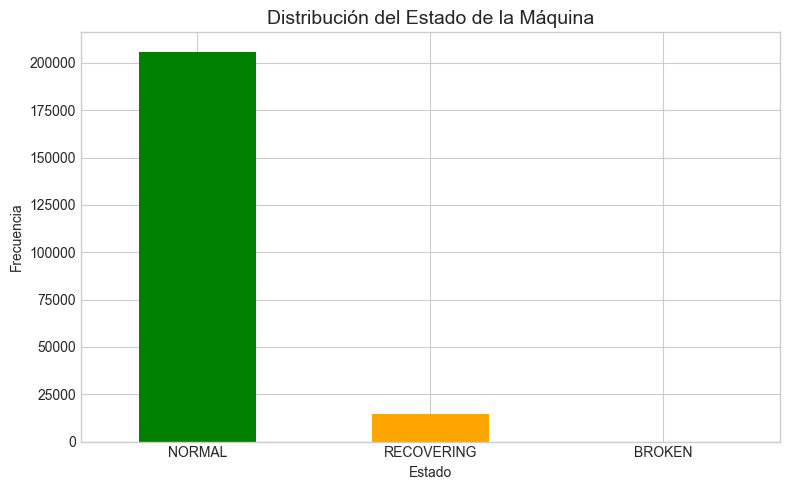

In [6]:
# Distribución de la variable objetivo (machine_status)
print("DISTRIBUCIÓN DE MACHINE_STATUS")
print("=" * 60)
status_counts = df['machine_status'].value_counts()
print(status_counts)
print(f"\nPorcentaje:")
print((status_counts / len(df) * 100).round(2))

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
status_counts.plot(kind='bar', color=['green', 'orange', 'red'][:len(status_counts)], ax=ax)
ax.set_title('Distribución del Estado de la Máquina', fontsize=14)
ax.set_xlabel('Estado')
ax.set_ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos

Preparamos los datos para la detección de outliers:
- Eliminamos columnas no necesarias (timestamp, índice)
- Tratamos valores faltantes
- Seleccionamos las características numéricas (sensores)

In [7]:
# Seleccionar solo columnas de sensores (numéricas)
sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
print(f"Número de sensores: {len(sensor_cols)}")
print(f"Sensores: {sensor_cols}")

# Crear DataFrame con solo datos de sensores
df_sensors = df[sensor_cols].copy()

# Guardar la etiqueta original para validación posterior
y_true = (df['machine_status'] != 'NORMAL').astype(int)
print(f"\nEtiquetas - Normal: {(y_true == 0).sum()}, Anómalo: {(y_true == 1).sum()}")

Número de sensores: 52
Sensores: ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03', 'sensor_04', 'sensor_05', 'sensor_06', 'sensor_07', 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26', 'sensor_27', 'sensor_28', 'sensor_29', 'sensor_30', 'sensor_31', 'sensor_32', 'sensor_33', 'sensor_34', 'sensor_35', 'sensor_36', 'sensor_37', 'sensor_38', 'sensor_39', 'sensor_40', 'sensor_41', 'sensor_42', 'sensor_43', 'sensor_44', 'sensor_45', 'sensor_46', 'sensor_47', 'sensor_48', 'sensor_49', 'sensor_50', 'sensor_51']

Etiquetas - Normal: 205836, Anómalo: 14484


In [8]:
# Tratamiento de valores faltantes - Imputación con la mediana
print("TRATAMIENTO DE VALORES FALTANTES")
print("=" * 60)
print(f"Valores faltantes antes: {df_sensors.isnull().sum().sum()}")

# Imputar con la mediana de cada columna
df_sensors = df_sensors.fillna(df_sensors.median())
print(f"Valores faltantes después: {df_sensors.isnull().sum().sum()}")

# Verificar
df_sensors.info()

TRATAMIENTO DE VALORES FALTANTES
Valores faltantes antes: 344574
Valores faltantes después: 220320
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 52 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   sensor_00  220320 non-null  float64
 1   sensor_01  220320 non-null  float64
 2   sensor_02  220320 non-null  float64
 3   sensor_03  220320 non-null  float64
 4   sensor_04  220320 non-null  float64
 5   sensor_05  220320 non-null  float64
 6   sensor_06  220320 non-null  float64
 7   sensor_07  220320 non-null  float64
 8   sensor_08  220320 non-null  float64
 9   sensor_09  220320 non-null  float64
 10  sensor_10  220320 non-null  float64
 11  sensor_11  220320 non-null  float64
 12  sensor_12  220320 non-null  float64
 13  sensor_13  220320 non-null  float64
 14  sensor_14  220320 non-null  float64
 15  sensor_15  0 non-null       float64
 16  sensor_16  220320 non-null  float64
 17  sensor

In [9]:
# Normalización de los datos (importante para algunos algoritmos)
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_sensors),
    columns=sensor_cols,
    index=df_sensors.index
)

print("DATOS NORMALIZADOS")
print("=" * 60)
df_scaled.describe().round(3)

DATOS NORMALIZADOS


,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,sensor_22,sensor_23,sensor_24,sensor_25,sensor_26,sensor_27,sensor_28,sensor_29,sensor_30,sensor_31,sensor_32,sensor_33,sensor_34,sensor_35,sensor_36,sensor_37,sensor_38,sensor_39,sensor_40,sensor_41,sensor_42,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51
count,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,0.0,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000,220320.000
mean,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,NaN,0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,NaN,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-5.897,-14.448,-4.829,-5.007,-4.082,-4.243,-6.303,-7.290,-7.536,-7.151,-3.429,-3.211,-2.881,-1.026,-3.043,NaN,-3.304,-3.261,-3.008,-2.964,-3.538,-3.091,-2.976,-3.162,-3.051,-2.939,-3.013,-2.953,-2.707,-2.550,-3.142,-2.960,-3.086,-3.184,-2.038,-3.013,-2.042,-1.617,-2.389,-1.111,-2.125,-1.840,-1.298,-1.757,-1.460,-1.306,-1.387,-1.642,-1.515,-1.593,-3.013,-1.651
25%,0.168,-0.389,-0.130,-0.378,0.250,-0.198,-0.074,0.029,-0.012,0.120,-0.063,-0.234,-0.045,-0.803,0.364,NaN,0.341,0.256,0.188,0.361,0.365,0.350,0.124,0.097,0.246,0.203,0.017,-0.313,-0.220,-0.254,0.069,-0.086,-0.167,0.022,-0.707,-0.522,-1.052,-0.851,-0.387,-0.260,-0.516,-0.356,-0.257,-0.389,-0.510,-0.494,-0.480,-0.505,-0.814,-0.490,-0.080,-0.206
50%,0.200,0.164,0.213,0.196,0.291,0.126,0.065,0.145,0.143,0.134,0.233,0.264,0.334,-0.601,0.382,NaN,0.368,0.317,0.300,0.375,0.378,0.368,0.466,0.203,0.382,0.412,0.306,-0.041,0.369,-0.050,0.278,0.192,0.286,0.172,-0.097,0.326,0.403,0.093,-0.017,-0.076,-0.114,-0.059,-0.029,-0.082,-0.186,-0.224,-0.203,-0.173,-0.156,-0.233,0.133,-0.047
75%,0.307,0.573,0.521,0.645,0.326,0.434,0.484,0.265,0.243,0.151,0.496,0.593,0.574,0.838,0.390,NaN,0.379,0.354,0.371,0.383,0.385,0.379,0.482,0.576,0.397,0.458,0.538,0.205,0.614,0.743,0.422,0.416,0.536,0.456,0.926,0.718,0.844,0.799,0.379,0.157,0.422,0.303,0.149,0.248,0.214,0.137,0.204,0.215,0.699,0.190,0.335,0.117
max,0.429,2.773,1.409,1.847,1.453,1.538,4.087,3.562,4.539,4.924,2.864,1.385,1.568,3.493,1.088,NaN,2.564,1.385,3.355,1.445,0.864,1.373,0.869,1.045,2.434,0.862,1.735,8.824,3.161,3.943,5.037,3.304,3.972,7.245,2.157,1.886,1.351,3.035,34.920,32.749,20.773,48.739,33.022,33.025,82.703,21.596,20.610,24.822,4.994,21.277,15.377,7.546


## 4. Métodos Estadísticos de Detección de Outliers

### 4.1 Método del Rango Intercuartílico (IQR)

El IQR es la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1). Los valores fuera del rango [Q1 - 1.5×IQR, Q3 + 1.5×IQR] se consideran outliers.

In [10]:
def detect_outliers_iqr(data, threshold=1.5):
    """
    Detecta outliers usando el método IQR.
    Retorna un array booleano donde True indica outlier.
    """
    outliers = np.zeros(len(data), dtype=bool)
    
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        # Marcar outliers para esta columna
        outliers = outliers | (data[col] < lower_bound) | (data[col] > upper_bound)
    
    return outliers

# Aplicar método IQR
outliers_iqr = detect_outliers_iqr(df_sensors)

print("RESULTADOS - MÉTODO IQR")
print("=" * 60)
print(f"Total de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_iqr.sum()}")
print(f"Porcentaje de outliers: {(outliers_iqr.sum() / len(df_sensors) * 100):.2f}%")

RESULTADOS - MÉTODO IQR
Total de observaciones: 220320
Outliers detectados: 170255
Porcentaje de outliers: 77.28%


In [ ]:
# Visualización de Outliers detectados por IQR
# Seleccionamos algunos sensores representativos para visualizar
selected_sensors_iqr = ['sensor_00', 'sensor_04', 'sensor_10', 'sensor_20']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, sensor in zip(axes, selected_sensors_iqr):
    # Calcular límites IQR para este sensor específico
    Q1 = df_sensors[sensor].quantile(0.25)
    Q3 = df_sensors[sensor].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identificar outliers en este sensor
    sensor_outliers = (df_sensors[sensor] < lower_bound) | (df_sensors[sensor] > upper_bound)
    
    # Graficar todos los valores
    ax.scatter(range(len(df_sensors)), df_sensors[sensor], 
               c='blue', s=1, alpha=0.3, label='Normal')
    
    # Resaltar outliers
    ax.scatter(np.where(sensor_outliers)[0], df_sensors.loc[sensor_outliers, sensor], 
               c='red', s=10, alpha=0.8, label='Outlier')
    
    # Dibujar límites IQR
    ax.axhline(y=upper_bound, color='orange', linestyle='--', linewidth=1.5, label=f'Límite superior ({upper_bound:.2f})')
    ax.axhline(y=lower_bound, color='green', linestyle='--', linewidth=1.5, label=f'Límite inferior ({lower_bound:.2f})')
    
    ax.set_title(f'{sensor}\nOutliers: {sensor_outliers.sum()} ({sensor_outliers.sum()/len(df_sensors)*100:.1f}%)')
    ax.set_xlabel('Índice')
    ax.set_ylabel('Valor')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Detección de Outliers por Método IQR', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Resumen de outliers por sensor
print("\nRESUMEN DE OUTLIERS POR SENSOR (Top 10):")
print("=" * 50)
outliers_per_sensor = {}
for col in sensor_cols:
    Q1 = df_sensors[col].quantile(0.25)
    Q3 = df_sensors[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_sensors[col] < lower) | (df_sensors[col] > upper)).sum()
    outliers_per_sensor[col] = n_outliers

# Ordenar por número de outliers
sorted_outliers = sorted(outliers_per_sensor.items(), key=lambda x: x[1], reverse=True)[:10]
for sensor, count in sorted_outliers:
    print(f"  {sensor}: {count} outliers ({count/len(df_sensors)*100:.2f}%)")

In [ ]:
# Boxplot de sensores seleccionados (visualización clásica de IQR)
fig, ax = plt.subplots(figsize=(14, 6))

# Seleccionar primeros 10 sensores para visualización clara
sensors_to_plot = sensor_cols[:10]
data_to_plot = df_sensors[sensors_to_plot]

# Crear boxplot
bp = ax.boxplot([data_to_plot[col].dropna() for col in sensors_to_plot], 
                labels=sensors_to_plot,
                patch_artist=True,
                flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))

# Colorear las cajas
colors_box = plt.cm.Blues(np.linspace(0.3, 0.7, len(sensors_to_plot)))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)

ax.set_title('Boxplot de Sensores - Los puntos rojos son Outliers (IQR)', fontsize=12)
ax.set_xlabel('Sensor')
ax.set_ylabel('Valor')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("📌 Los puntos rojos fuera de los bigotes representan outliers según el método IQR")

### 4.2 Método Z-Score

El Z-score mide cuántas desviaciones estándar está un valor de la media. Valores con |Z| > 3 generalmente se consideran outliers.

In [11]:
def detect_outliers_zscore(data, threshold=3):
    """
    Detecta outliers usando el método Z-score.
    Retorna un array booleano donde True indica outlier.
    """
    z_scores = np.abs(stats.zscore(data, nan_policy='omit'))
    outliers = (z_scores > threshold).any(axis=1)
    return outliers

# Aplicar método Z-score
outliers_zscore = detect_outliers_zscore(df_sensors)

print("RESULTADOS - MÉTODO Z-SCORE")
print("=" * 60)
print(f"Total de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_zscore.sum()}")
print(f"Porcentaje de outliers: {(outliers_zscore.sum() / len(df_sensors) * 100):.2f}%")

RESULTADOS - MÉTODO Z-SCORE
Total de observaciones: 220320
Outliers detectados: 55119
Porcentaje de outliers: 25.02%


## 5. Isolation Forest

Isolation Forest es un algoritmo basado en árboles que aísla anomalías en lugar de perfilar puntos normales. Los outliers son más fáciles de aislar, por lo que requieren menos particiones.

**Parámetros clave:**
- `contamination`: Proporción esperada de outliers en el dataset
- `n_estimators`: Número de árboles base
- `max_samples`: Número de muestras para entrenar cada árbol

In [12]:
# Configurar Isolation Forest
# Estimamos la contaminación basándonos en el porcentaje de estados anómalos conocidos
contamination_rate = y_true.mean()
print(f"Tasa de contaminación estimada: {contamination_rate:.4f}")

# Crear el modelo
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate if contamination_rate > 0 else 0.01,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# Entrenar y predecir
# -1 para outliers, 1 para inliers
y_pred_iso = iso_forest.fit_predict(df_scaled)
outliers_iso = (y_pred_iso == -1)

# Obtener scores de anomalía (más negativo = más anómalo)
anomaly_scores_iso = iso_forest.decision_function(df_scaled)

print("\nRESULTADOS - ISOLATION FOREST")
print("=" * 60)
print(f"Total de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_iso.sum()}")
print(f"Porcentaje de outliers: {(outliers_iso.sum() / len(df_sensors) * 100):.2f}%")

Tasa de contaminación estimada: 0.0657

RESULTADOS - ISOLATION FOREST
Total de observaciones: 220320
Outliers detectados: 14484
Porcentaje de outliers: 6.57%


## 6. Local Outlier Factor (LOF)

LOF mide la densidad local de cada punto comparada con la de sus vecinos. Los puntos con densidad significativamente menor que sus vecinos se consideran outliers.

**Parámetros clave:**
- `n_neighbors`: Número de vecinos a considerar
- `contamination`: Proporción esperada de outliers

In [13]:
# Limpiar matriz de entrada para LOF (LOF no acepta NaN)
X_lof = df_scaled.copy()
X_lof = X_lof.replace([np.inf, -np.inf], np.nan)
X_lof = X_lof.dropna(axis=1, how='all')   # elimina columnas completamente vacías (ej. sensor_15)
X_lof = X_lof.fillna(X_lof.median())      # imputa cualquier NaN restante

# Configurar Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=contamination_rate if contamination_rate > 0 else 0.01,
    novelty=False,
    n_jobs=-1
)

# Predecir
# -1 para outliers, 1 para inliers
y_pred_lof = lof.fit_predict(X_lof)
outliers_lof = (y_pred_lof == -1)

# Obtener scores de anomalía
anomaly_scores_lof = lof.negative_outlier_factor_

print("RESULTADOS - LOCAL OUTLIER FACTOR (LOF)")
print("=" * 60)
print(f"Total de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_lof.sum()}")
print(f"Porcentaje de outliers: {(outliers_lof.sum() / len(df_sensors) * 100):.2f}%")

RESULTADOS - LOCAL OUTLIER FACTOR (LOF)
Total de observaciones: 220320
Outliers detectados: 14484
Porcentaje de outliers: 6.57%


## 7. Detección de Outliers Online con River

### ¿Por qué detección Online vs Offline?

| Característica | Offline (Batch) | Online (Streaming) |
|----------------|-----------------|-------------------|
| **Datos** | Dataset completo disponible | Datos llegan uno a uno |
| **Memoria** | Alta (todo en memoria) | Baja (procesa incrementalmente) |
| **Actualización** | Requiere reentrenamiento completo | Se adapta continuamente |
| **Aplicaciones** | Análisis histórico | Monitoreo en tiempo real |

**River** es una librería de Python para machine learning en streaming. Permite procesar datos uno por uno, actualizando el modelo de forma incremental - ideal para sensores IoT y monitoreo en tiempo real.

### Algoritmos de River para detección de anomalías:
- **Half-Space Trees (HST)**: Versión en streaming de Isolation Forest
- **One-Class SVM incremental**: SVM adaptado para streaming
- **StandardAbsoluteDeviation**: Método estadístico basado en desviación

In [14]:
# Instalar River si no está disponible
try:
    import river
    print(f"River ya está instalado - versión {river.__version__}")
except ImportError:
    print("Instalando River...")
    !pip install river
    import river
    print(f"River instalado correctamente - versión {river.__version__}")

# Importar módulos de River para detección de anomalías
from river import anomaly
from river import compose
from river import preprocessing as river_preprocessing

print("Módulos de River importados correctamente ✓")

River ya está instalado - versión 0.23.0
Módulos de River importados correctamente ✓


### 7.1 Half-Space Trees (HST)

Half-Space Trees es la versión en streaming de Isolation Forest. Funciona dividiendo el espacio de características con hiperplanos aleatorios y manteniendo contadores de masa en cada nodo.

**Parámetros clave:**
- `n_trees`: Número de árboles (similar a n_estimators)
- `height`: Profundidad máxima de los árboles
- `window_size`: Tamaño de la ventana para el cálculo de anomalías

In [15]:
# Configurar Half-Space Trees para detección online
hst = anomaly.HalfSpaceTrees(
    n_trees=25,
    height=8,
    window_size=250,
    seed=42
)

# Convertir DataFrame a diccionarios para procesamiento online
# River trabaja con diccionarios (cada fila es un dict)
print("DETECCIÓN ONLINE - HALF-SPACE TREES")
print("=" * 60)

# Almacenar scores y predicciones
hst_scores = []
outliers_hst = []
threshold_hst = 0.5  # Umbral para clasificar como outlier

# Simular procesamiento en streaming (un dato a la vez)
for i in range(len(df_sensors)):
    # Convertir fila a diccionario
    x = df_scaled.iloc[i].to_dict()
    
    # Obtener score de anomalía ANTES de actualizar el modelo
    # En River, score_one() da valores entre 0 y 1 (más alto = más anómalo)
    score = hst.score_one(x)
    hst_scores.append(score)
    
    # Clasificar como outlier si el score supera el umbral
    outliers_hst.append(score > threshold_hst)
    
    # Actualizar el modelo con el nuevo dato (aprendizaje incremental)
    hst.learn_one(x)
    
    # Mostrar progreso cada 50000 registros
    if (i + 1) % 50000 == 0:
        print(f"  Procesados: {i + 1}/{len(df_sensors)} registros...")

# Convertir a arrays numpy
hst_scores = np.array(hst_scores)
outliers_hst = np.array(outliers_hst)

print(f"\nTotal de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_hst.sum()}")
print(f"Porcentaje de outliers: {(outliers_hst.sum() / len(df_sensors) * 100):.2f}%")

DETECCIÓN ONLINE - HALF-SPACE TREES
  Procesados: 50000/220320 registros...
  Procesados: 100000/220320 registros...
  Procesados: 150000/220320 registros...
  Procesados: 200000/220320 registros...

Total de observaciones: 220320
Outliers detectados: 146122
Porcentaje de outliers: 66.32%


### 7.2 One-Class SVM Incremental

River también proporciona una versión incremental del One-Class SVM que puede actualizarse con cada nueva observación.

In [16]:
# Configurar Standard Absolute Deviation para detección online (más eficiente)
# Este método es más rápido y funciona bien para datos univariados/multivariados

# Crear un detector incremental por desviación estándar
from collections import defaultdict

class OnlineZScore:
    """
    Detector de anomalías online usando Z-Score con estadísticas incrementales.
    Implementa el algoritmo de Welford para calcular media y varianza de forma online.
    """
    def __init__(self, threshold=3.0, warm_up=100):
        self.threshold = threshold
        self.warm_up = warm_up
        self.n = defaultdict(int)
        self.mean = defaultdict(float)
        self.M2 = defaultdict(float)
    
    def update(self, x):
        """Actualiza las estadísticas con una nueva observación (algoritmo de Welford)."""
        for key, value in x.items():
            if value is None or np.isnan(value):
                continue
            self.n[key] += 1
            delta = value - self.mean[key]
            self.mean[key] += delta / self.n[key]
            delta2 = value - self.mean[key]
            self.M2[key] += delta * delta2
    
    def score_one(self, x):
        """Calcula el score de anomalía (máximo z-score absoluto)."""
        max_zscore = 0
        for key, value in x.items():
            if value is None or np.isnan(value):
                continue
            if self.n[key] < self.warm_up:
                continue
            variance = self.M2[key] / self.n[key]
            if variance > 0:
                std = np.sqrt(variance)
                zscore = abs(value - self.mean[key]) / std
                max_zscore = max(max_zscore, zscore)
        return max_zscore
    
    def is_anomaly(self, x):
        """Determina si una observación es anómala."""
        return self.score_one(x) > self.threshold

# Crear detector online
online_zscore = OnlineZScore(threshold=3.0, warm_up=100)

print("DETECCIÓN ONLINE - Z-SCORE INCREMENTAL")
print("=" * 60)

# Almacenar resultados
zscore_online_scores = []
outliers_zscore_online = []

# Procesamiento en streaming
for i in range(len(df_sensors)):
    x = df_scaled.iloc[i].to_dict()
    
    # Calcular score ANTES de actualizar
    score = online_zscore.score_one(x)
    zscore_online_scores.append(score)
    outliers_zscore_online.append(online_zscore.is_anomaly(x))
    
    # Actualizar estadísticas
    online_zscore.update(x)
    
    if (i + 1) % 50000 == 0:
        print(f"  Procesados: {i + 1}/{len(df_sensors)} registros...")

zscore_online_scores = np.array(zscore_online_scores)
outliers_zscore_online = np.array(outliers_zscore_online)

print(f"\nTotal de observaciones: {len(df_sensors)}")
print(f"Outliers detectados: {outliers_zscore_online.sum()}")
print(f"Porcentaje de outliers: {(outliers_zscore_online.sum() / len(df_sensors) * 100):.2f}%")

DETECCIÓN ONLINE - Z-SCORE INCREMENTAL
  Procesados: 50000/220320 registros...
  Procesados: 100000/220320 registros...
  Procesados: 150000/220320 registros...
  Procesados: 200000/220320 registros...

Total de observaciones: 220320
Outliers detectados: 69727
Porcentaje de outliers: 31.65%


### 7.3 Evaluación y Comparación: Online vs Offline

Comparamos el rendimiento de los métodos online con los offline para evaluar su efectividad en la detección de anomalías.

In [17]:
# Definir evaluate_method si aún no existe (por ejecución fuera de orden en Jupyter)
if 'evaluate_method' not in globals():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    def evaluate_method(y_true, y_pred, method_name):
        """Evalúa un método de detección de outliers."""
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        return {
            'Método': method_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }

# Evaluar métodos online
eval_online = []
eval_online.append(evaluate_method(y_true, outliers_hst.astype(int), 'HST (Online)'))
eval_online.append(evaluate_method(y_true, outliers_zscore_online.astype(int), 'Z-Score Online'))

# Recuperar/crear evaluaciones offline de forma robusta
if 'evaluations' in globals():
    offline_evaluations = evaluations
elif 'eval_df' in globals():
    offline_evaluations = eval_df.to_dict('records')
else:
    offline_evaluations = []
    offline_evaluations.append(evaluate_method(y_true, outliers_iqr.astype(int), 'IQR'))
    offline_evaluations.append(evaluate_method(y_true, outliers_zscore.astype(int), 'Z-Score'))
    offline_evaluations.append(evaluate_method(y_true, outliers_iso.astype(int), 'Isolation Forest'))
    offline_evaluations.append(evaluate_method(y_true, outliers_lof.astype(int), 'LOF'))

# Combinar con evaluaciones online
eval_all = offline_evaluations + eval_online
eval_all_df = pd.DataFrame(eval_all)

print("COMPARACIÓN: MÉTODOS OFFLINE vs ONLINE")
print("=" * 70)
print(eval_all_df.round(4).to_string(index=False))

# Crear DataFrame de resultados online
results_online_df = pd.DataFrame({
    'Método': ['HST (Online)', 'Z-Score Online'],
    'Outliers Detectados': [outliers_hst.sum(), outliers_zscore_online.sum()],
    'Porcentaje (%)': [
        (outliers_hst.sum() / len(df_sensors) * 100),
        (outliers_zscore_online.sum() / len(df_sensors) * 100)
    ],
    'Tipo': ['Online', 'Online']
})

# Recuperar/crear resultados offline de forma robusta
if 'results_df' in globals():
    results_offline_df = results_df.copy()
else:
    results_offline_df = pd.DataFrame({
        'Método': ['IQR', 'Z-Score', 'Isolation Forest', 'LOF'],
        'Outliers Detectados': [
            outliers_iqr.sum(),
            outliers_zscore.sum(),
            outliers_iso.sum(),
            outliers_lof.sum()
        ],
        'Porcentaje (%)': [
            (outliers_iqr.sum() / len(df_sensors) * 100),
            (outliers_zscore.sum() / len(df_sensors) * 100),
            (outliers_iso.sum() / len(df_sensors) * 100),
            (outliers_lof.sum() / len(df_sensors) * 100)
        ]
    })

results_offline_df['Tipo'] = 'Offline'
results_all_df = pd.concat([results_offline_df, results_online_df], ignore_index=True)

print("\n" + "=" * 70)
print("OUTLIERS DETECTADOS POR CADA MÉTODO")
print("=" * 70)
print(results_all_df.to_string(index=False))

COMPARACIÓN: MÉTODOS OFFLINE vs ONLINE
          Método  Accuracy  Precision  Recall  F1-Score
             IQR    0.2929     0.0850  0.9997    0.1568
         Z-Score    0.8139     0.2594  0.9872    0.4109
Isolation Forest    0.9350     0.5054  0.5054    0.5054
             LOF    0.8895     0.1598  0.1598    0.1598
    HST (Online)    0.3000     0.0219  0.2205    0.0398
  Z-Score Online    0.7492     0.2076  0.9994    0.3438

OUTLIERS DETECTADOS POR CADA MÉTODO
          Método  Outliers Detectados  Porcentaje (%)    Tipo
             IQR               170255       77.276235 Offline
         Z-Score                55119       25.017702 Offline
Isolation Forest                14484        6.574074 Offline
             LOF                14484        6.574074 Offline
    HST (Online)               146122       66.322622  Online
  Z-Score Online                69727       31.648057  Online


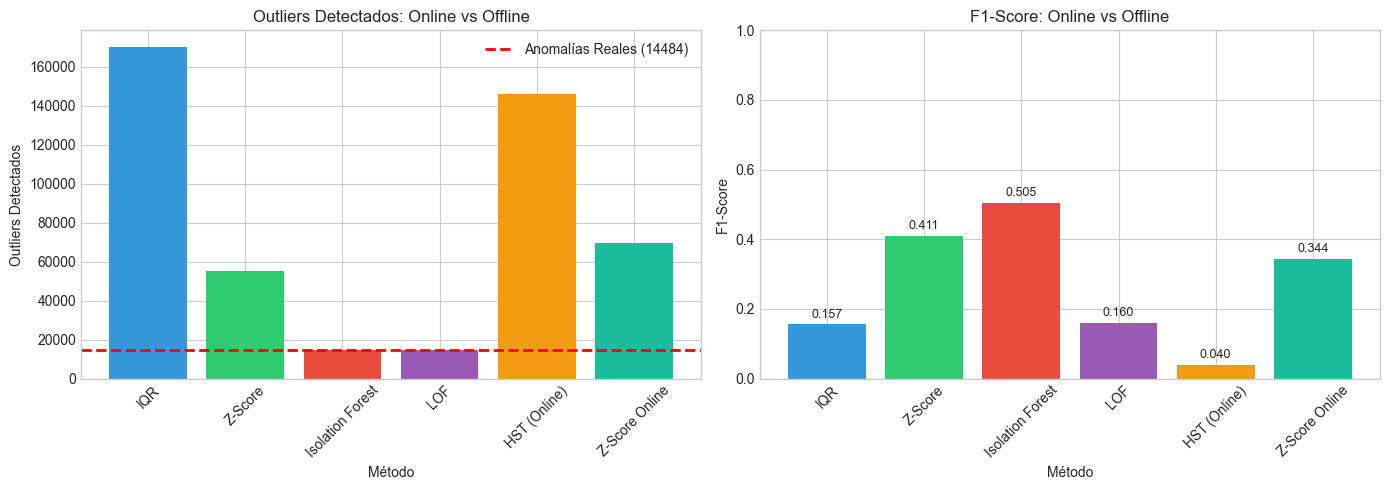

In [18]:
# Visualización comparativa Online vs Offline
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Número de outliers detectados
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
bars = axes[0].bar(results_all_df['Método'], results_all_df['Outliers Detectados'], color=colors)
axes[0].set_xlabel('Método')
axes[0].set_ylabel('Outliers Detectados')
axes[0].set_title('Outliers Detectados: Online vs Offline')
axes[0].tick_params(axis='x', rotation=45)

# Añadir línea de referencia para anomalías reales
axes[0].axhline(y=y_true.sum(), color='red', linestyle='--', linewidth=2, label=f'Anomalías Reales ({y_true.sum()})')
axes[0].legend()

# Gráfico 2: Métricas F1-Score
methods_order = eval_all_df['Método'].tolist()
f1_scores = eval_all_df['F1-Score'].tolist()
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']
bars2 = axes[1].bar(methods_order, f1_scores, color=colors_metrics)
axes[1].set_xlabel('Método')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score: Online vs Offline')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 1)

# Añadir valores sobre las barras
for bar, f1 in zip(bars2, f1_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{f1:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [19]:
# Visualización temporal: evolución del score de anomalía online
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot 1: Estado real
axes[0].scatter(df['timestamp'], y_true, c=y_true, cmap='coolwarm', s=1, alpha=0.5)
axes[0].set_ylabel('Estado Real')
axes[0].set_title('Detección de Anomalías Online en el Tiempo')

# Plot 2: Scores de HST
axes[1].plot(df['timestamp'], hst_scores, linewidth=0.5, alpha=0.7, color='blue')
axes[1].axhline(y=threshold_hst, color='red', linestyle='--', label=f'Umbral ({threshold_hst})')
axes[1].fill_between(df['timestamp'], hst_scores, threshold_hst, 
                     where=(hst_scores > threshold_hst), alpha=0.3, color='red')
axes[1].set_ylabel('Score HST')
axes[1].legend(loc='upper right')

# Plot 3: Detección HST vs Real
axes[2].scatter(df['timestamp'], outliers_hst.astype(int), c=outliers_hst.astype(int), 
               cmap='coolwarm', s=1, alpha=0.5, label='Predicción HST')
axes[2].set_ylabel('HST Online')
axes[2].set_xlabel('Tiempo')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### 7.4 Ejemplo de Uso en Producción: Monitoreo en Tiempo Real

Este ejemplo muestra cómo implementar detección de anomalías en tiempo real para un sistema de sensores IoT, simulando la llegada de datos en streaming.

In [ ]:
class MonitorSensoresOnline:
    """
    Sistema de monitoreo de sensores en tiempo real usando detección de anomalías online.
    Implementa Half-Space Trees de River para detección incremental.
    """
    def __init__(self, n_trees=25, height=8, window_size=250, threshold=0.5):
        self.detector = anomaly.HalfSpaceTrees(
            n_trees=n_trees,
            height=height,
            window_size=window_size,
            seed=42
        )
        self.threshold = threshold
        self.alertas = []
        self.contador = 0
    
    def procesar_lectura(self, lectura_sensores, timestamp=None):
        """
        Procesa una nueva lectura de sensores y detecta si es anómala.
        
        Args:
            lectura_sensores: dict con valores de cada sensor
            timestamp: marca temporal (opcional)
        
        Returns:
            dict con resultado del análisis
        """
        self.contador += 1
        
        # Calcular score de anomalía
        score = self.detector.score_one(lectura_sensores)
        es_anomalia = score > self.threshold
        
        # Actualizar modelo con nueva lectura
        self.detector.learn_one(lectura_sensores)
        
        resultado = {
            'id': self.contador,
            'timestamp': timestamp,
            'score': score,
            'es_anomalia': es_anomalia
        }
        
        # Registrar alerta si es anomalía
        if es_anomalia:
            self.alertas.append(resultado)
        
        return resultado
    
    def obtener_alertas(self, ultimas_n=10):
        """Retorna las últimas n alertas registradas."""
        return self.alertas[-ultimas_n:]
    
    def estadisticas(self):
        """Retorna estadísticas del monitoreo."""
        return {
            'total_lecturas': self.contador,
            'total_alertas': len(self.alertas),
            'tasa_anomalias': len(self.alertas) / max(1, self.contador) * 100
        }

# Demostración del sistema de monitoreo
print("DEMOSTRACIÓN: SISTEMA DE MONITOREO EN TIEMPO REAL")
print("=" * 70)

monitor = MonitorSensoresOnline(threshold=0.5)

# Simular llegada de datos en streaming (últimos 1000 registros)
print("\nSimulando llegada de datos en streaming (500 lecturas)...")
for i in range(500):
    lectura = df_scaled.iloc[-(500-i)].to_dict()
    timestamp = df['timestamp'].iloc[-(500-i)]
    resultado = monitor.procesar_lectura(lectura, timestamp)
    
    # Mostrar alertas en "tiempo real" (solo primeras 5)
    if resultado['es_anomalia'] and len(monitor.alertas) <= 5:
        print(f"  ⚠️  ALERTA #{resultado['id']}: Score={resultado['score']:.3f} @ {resultado['timestamp']}")

# Mostrar estadísticas finales
stats = monitor.estadisticas()
print(f"\n📊 ESTADÍSTICAS DEL MONITOREO:")
print(f"   - Lecturas procesadas: {stats['total_lecturas']}")
print(f"   - Alertas generadas: {stats['total_alertas']}")
print(f"   - Tasa de anomalías: {stats['tasa_anomalias']:.2f}%")

print("\n🔔 ÚLTIMAS 5 ALERTAS:")
for alerta in monitor.obtener_alertas(5):
    print(f"   ID={alerta['id']}, Score={alerta['score']:.3f}, Timestamp={alerta['timestamp']}")

## 8. Visualización y Comparación de Resultados

### 8.1 Comparación de métodos

COMPARACIÓN DE MÉTODOS DE DETECCIÓN DE OUTLIERS
          Método  Outliers Detectados  Porcentaje (%)
             IQR               170255       77.276235
         Z-Score                55119       25.017702
Isolation Forest                14484        6.574074
             LOF                14484        6.574074


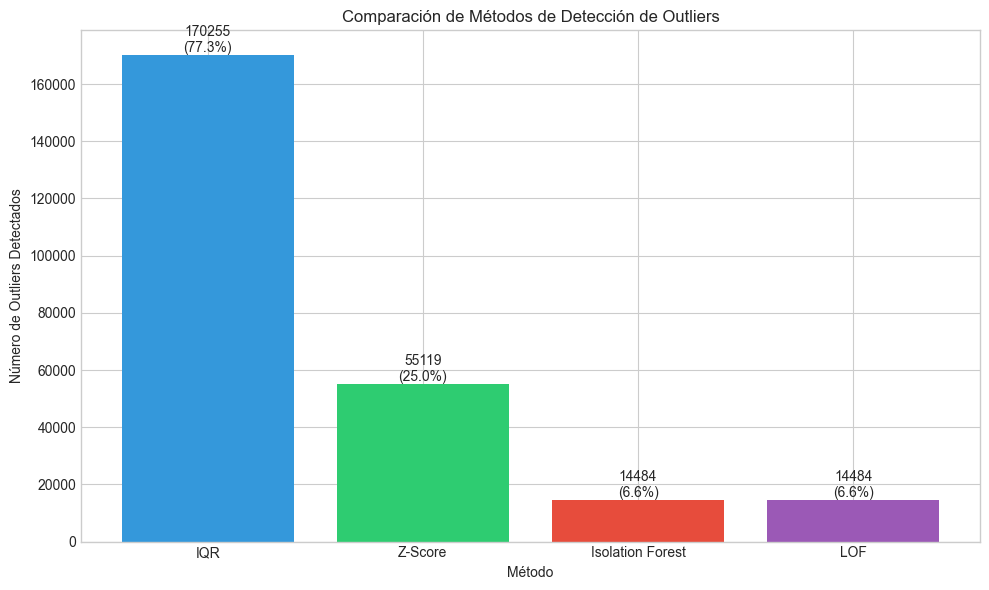

In [ ]:
# Crear DataFrame de resultados
results_df = pd.DataFrame({
    'Método': ['IQR', 'Z-Score', 'Isolation Forest', 'LOF'],
    'Outliers Detectados': [
        outliers_iqr.sum(),
        outliers_zscore.sum(),
        outliers_iso.sum(),
        outliers_lof.sum()
    ],
    'Porcentaje (%)': [
        (outliers_iqr.sum() / len(df_sensors) * 100),
        (outliers_zscore.sum() / len(df_sensors) * 100),
        (outliers_iso.sum() / len(df_sensors) * 100),
        (outliers_lof.sum() / len(df_sensors) * 100)
    ]
})

print("COMPARACIÓN DE MÉTODOS DE DETECCIÓN DE OUTLIERS")
print("=" * 60)
print(results_df.to_string(index=False))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(results_df['Método'], results_df['Outliers Detectados'], 
              color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
ax.set_xlabel('Método')
ax.set_ylabel('Número de Outliers Detectados')
ax.set_title('Comparación de Métodos de Detección de Outliers')

# Añadir valores en las barras
for bar, pct in zip(bars, results_df['Porcentaje (%)']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 8.2 Evaluación con etiquetas reales (machine_status)

Dado que tenemos las etiquetas reales (machine_status), podemos evaluar el rendimiento de cada método.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_method(y_true, y_pred, method_name):
    """Evalúa un método de detección de outliers."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return {
        'Método': method_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluar cada método
evaluations = []
evaluations.append(evaluate_method(y_true, outliers_iqr.astype(int), 'IQR'))
evaluations.append(evaluate_method(y_true, outliers_zscore.astype(int), 'Z-Score'))
evaluations.append(evaluate_method(y_true, outliers_iso.astype(int), 'Isolation Forest'))
evaluations.append(evaluate_method(y_true, outliers_lof.astype(int), 'LOF'))

# Crear DataFrame de evaluación
eval_df = pd.DataFrame(evaluations)
print("MÉTRICAS DE EVALUACIÓN")
print("=" * 60)
print(eval_df.round(4).to_string(index=False))

MÉTRICAS DE EVALUACIÓN
          Método  Accuracy  Precision  Recall  F1-Score
             IQR    0.2929     0.0850  0.9997    0.1568
         Z-Score    0.8139     0.2594  0.9872    0.4109
Isolation Forest    0.9350     0.5054  0.5054    0.5054
             LOF    0.8895     0.1598  0.1598    0.1598


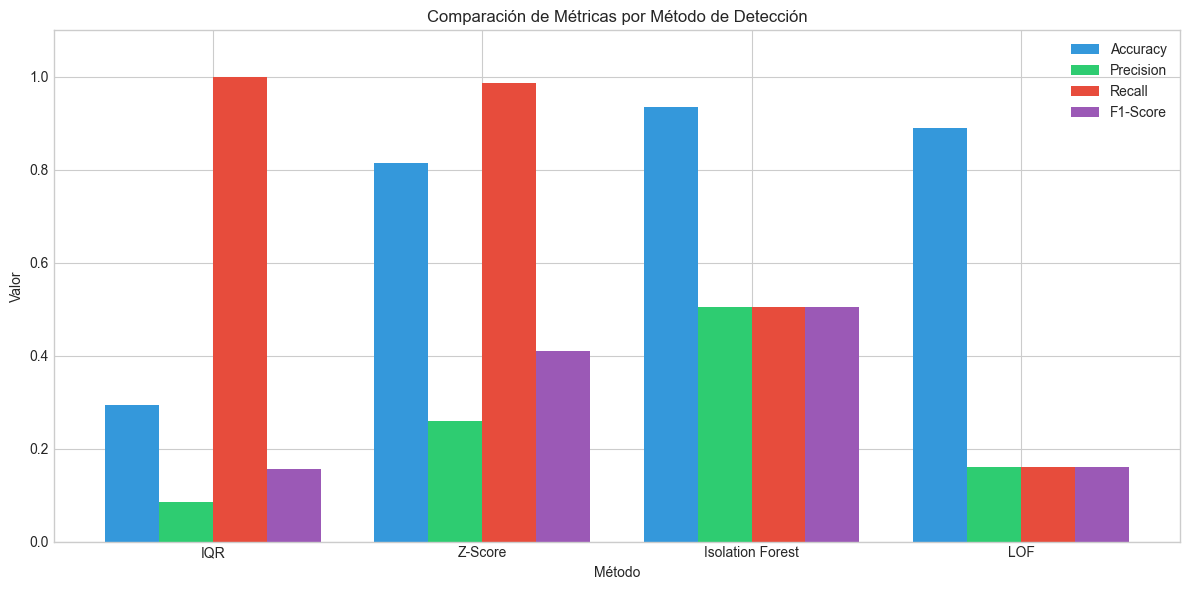

In [ ]:
# Visualización de métricas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(eval_df['Método']))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i*width, eval_df[metric], width, label=metric, color=colors[i])

ax.set_xlabel('Método')
ax.set_ylabel('Valor')
ax.set_title('Comparación de Métricas por Método de Detección')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df['Método'])
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

### 8.3 Matrices de Confusión

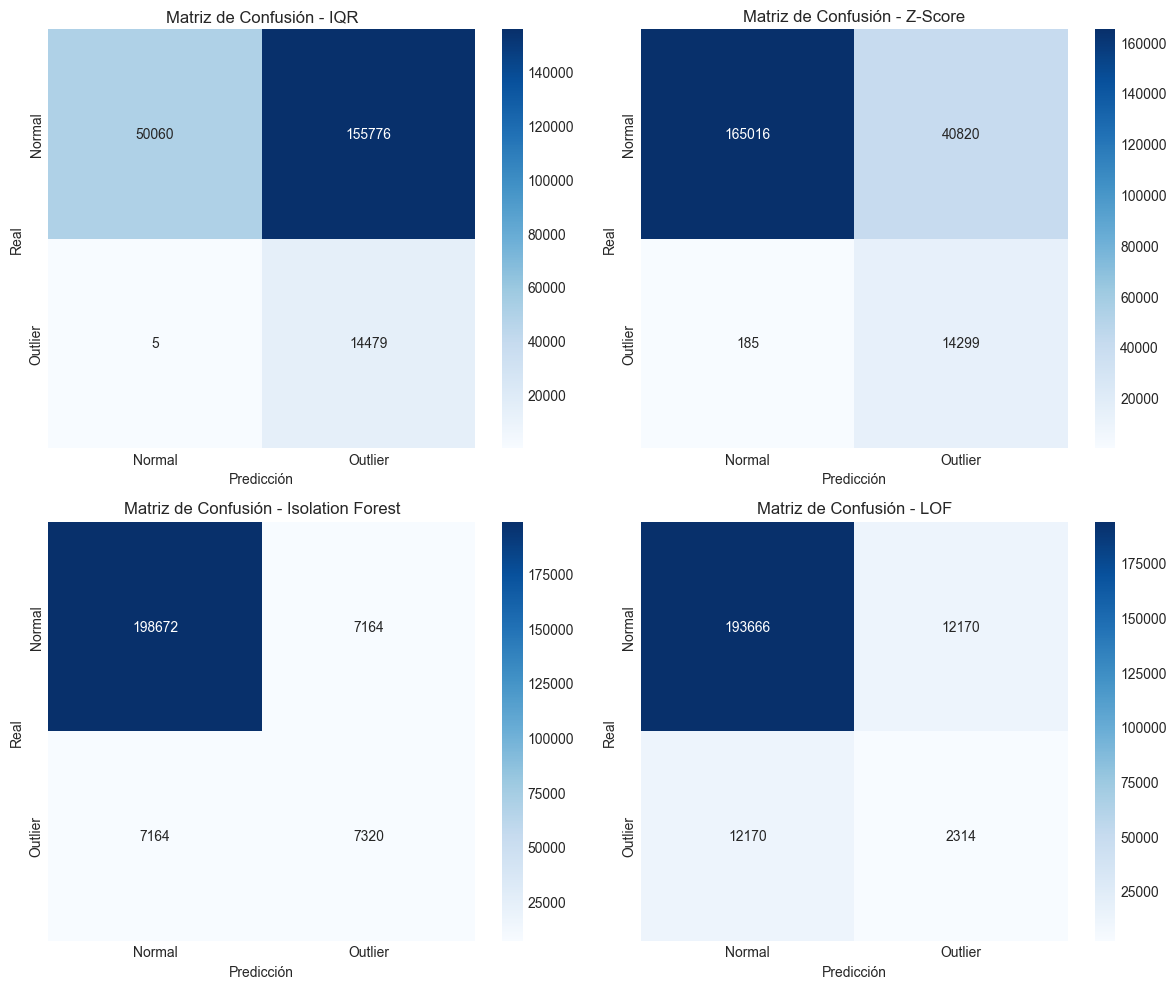

In [ ]:
# Matrices de confusión para cada método
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

methods = [
    ('IQR', outliers_iqr),
    ('Z-Score', outliers_zscore),
    ('Isolation Forest', outliers_iso),
    ('LOF', outliers_lof)
]

for ax, (name, preds) in zip(axes.flatten(), methods):
    cm = confusion_matrix(y_true, preds.astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Outlier'],
                yticklabels=['Normal', 'Outlier'])
    ax.set_title(f'Matriz de Confusión - {name}')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### 8.4 Visualización Temporal de Anomalías

Visualizamos la detección de outliers a lo largo del tiempo junto con el estado real de la máquina.

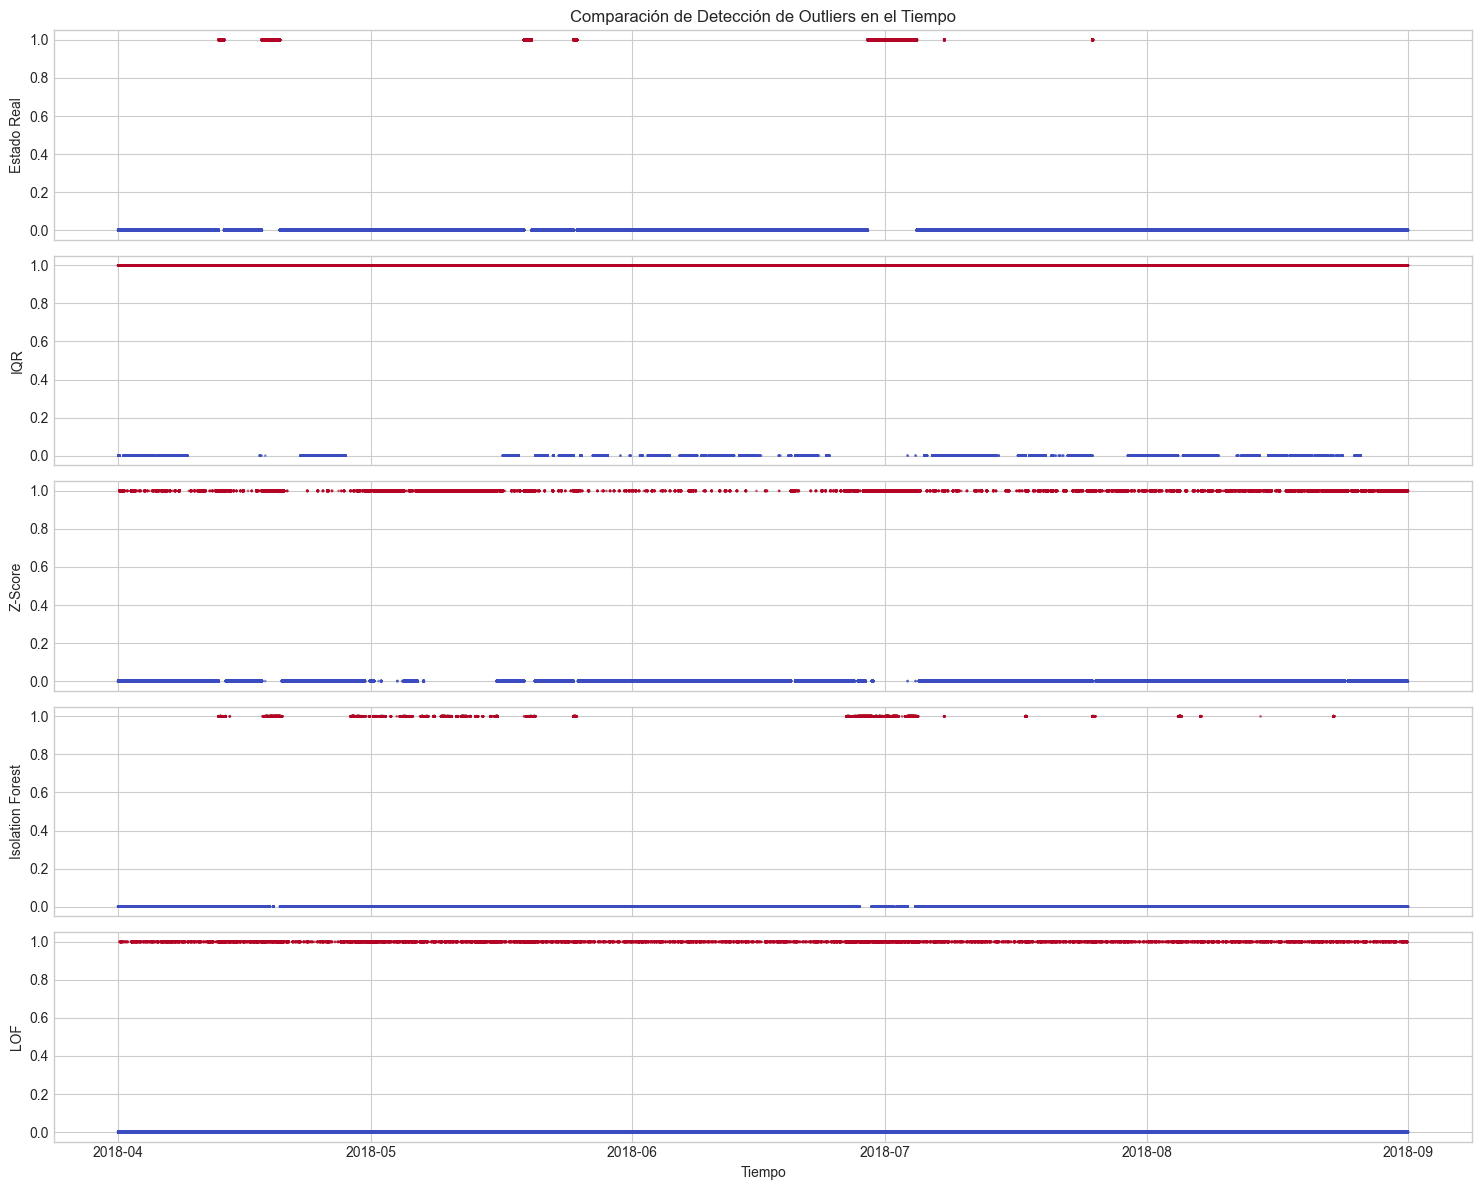

In [ ]:
# Convertir timestamp a datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Crear figura con subplots
fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

# Plot de estado real
axes[0].scatter(df['timestamp'], y_true, c=y_true, cmap='coolwarm', s=1, alpha=0.5)
axes[0].set_ylabel('Estado Real')
axes[0].set_title('Comparación de Detección de Outliers en el Tiempo')

# Plot de cada método
methods_data = [
    ('IQR', outliers_iqr),
    ('Z-Score', outliers_zscore),
    ('Isolation Forest', outliers_iso),
    ('LOF', outliers_lof)
]

for i, (name, outliers) in enumerate(methods_data, 1):
    axes[i].scatter(df['timestamp'], outliers.astype(int), c=outliers.astype(int), 
                   cmap='coolwarm', s=1, alpha=0.5)
    axes[i].set_ylabel(name)

axes[-1].set_xlabel('Tiempo')
plt.tight_layout()
plt.show()

### 8.5 Distribución de Scores de Anomalía

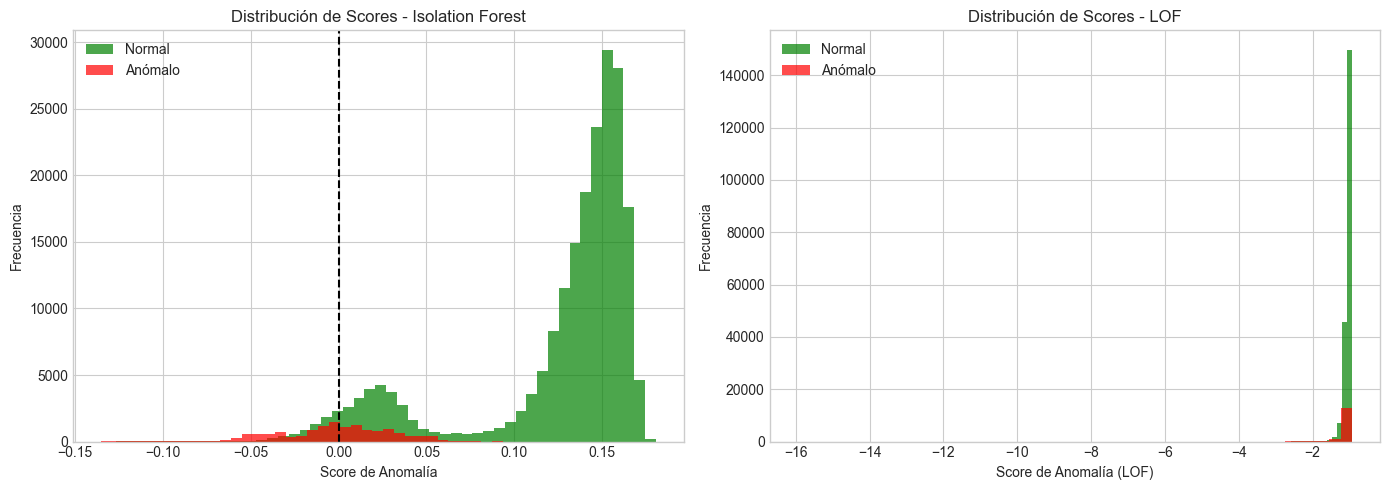

In [ ]:
# Distribución de scores de anomalía para Isolation Forest y LOF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Isolation Forest scores
axes[0].hist(anomaly_scores_iso[y_true == 0], bins=50, alpha=0.7, label='Normal', color='green')
axes[0].hist(anomaly_scores_iso[y_true == 1], bins=50, alpha=0.7, label='Anómalo', color='red')
axes[0].set_xlabel('Score de Anomalía')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores - Isolation Forest')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', label='Umbral')

# LOF scores
axes[1].hist(anomaly_scores_lof[y_true == 0], bins=50, alpha=0.7, label='Normal', color='green')
axes[1].hist(anomaly_scores_lof[y_true == 1], bins=50, alpha=0.7, label='Anómalo', color='red')
axes[1].set_xlabel('Score de Anomalía (LOF)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Scores - LOF')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Análisis por Sensor Individual

Visualizamos el comportamiento de algunos sensores específicos para entender mejor los patrones de anomalía.

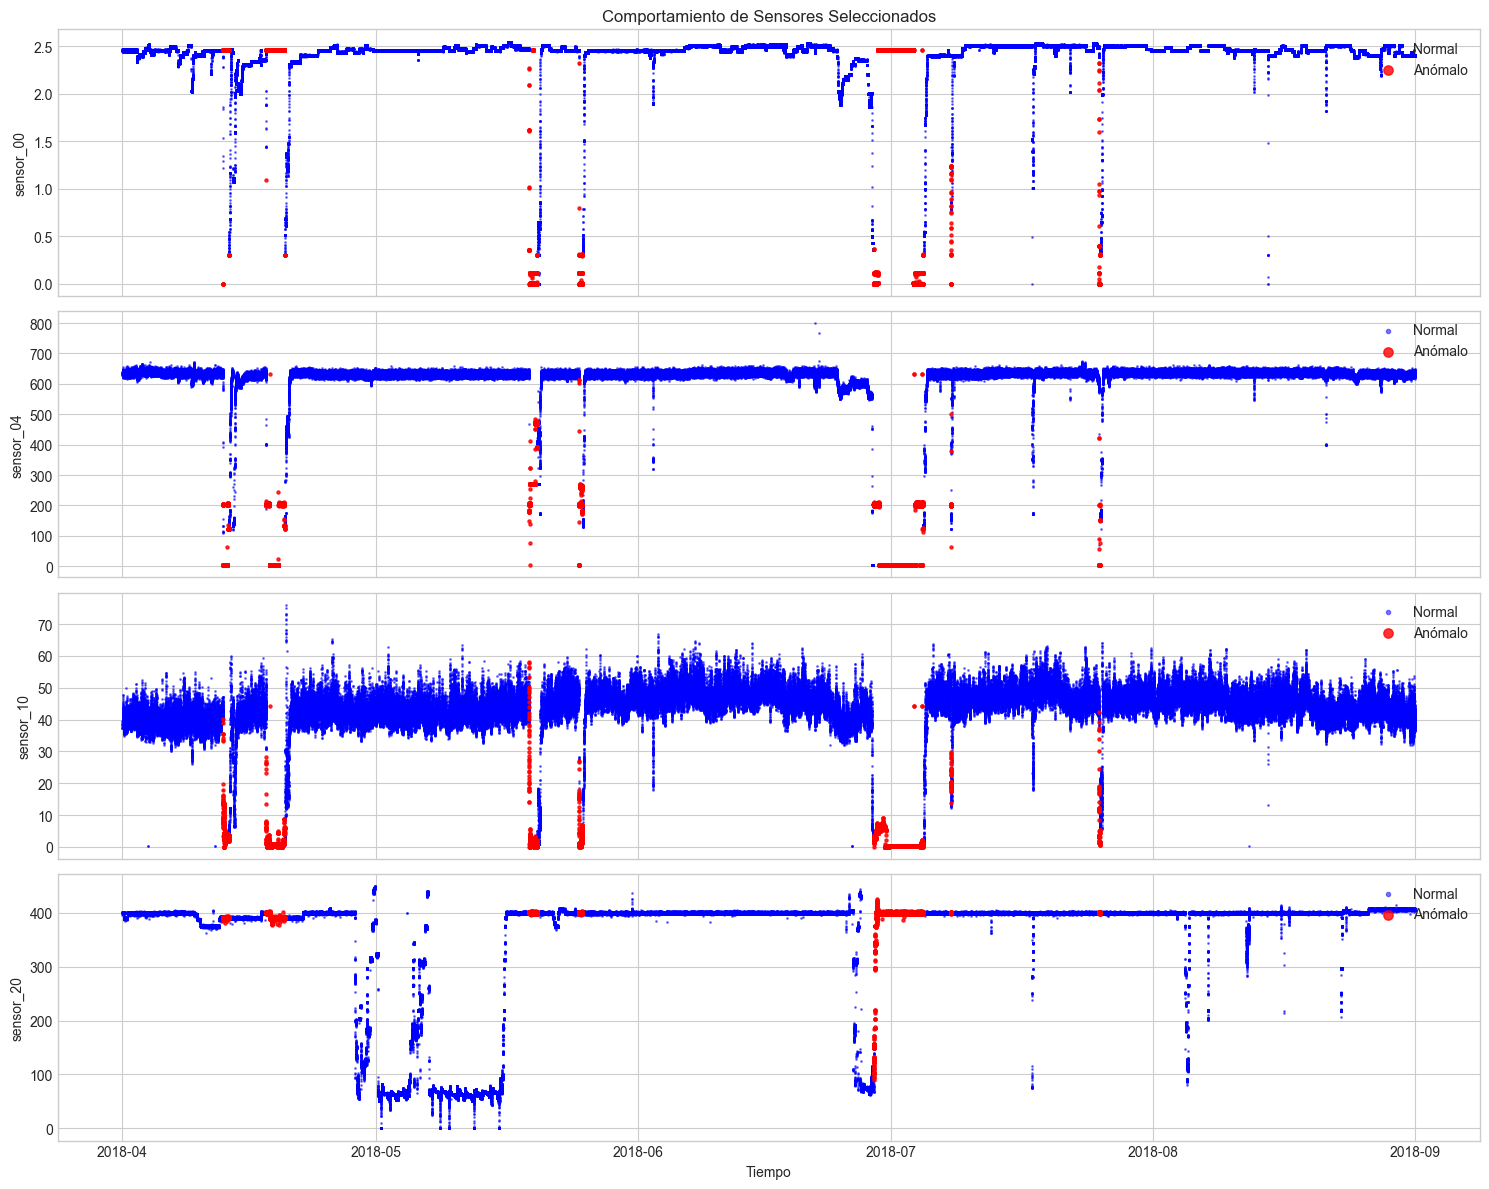

In [ ]:
# Seleccionar algunos sensores para visualizar
selected_sensors = ['sensor_00', 'sensor_04', 'sensor_10', 'sensor_20']

fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(15, 12), sharex=True)

for ax, sensor in zip(axes, selected_sensors):
    # Valores normales
    normal_mask = y_true == 0
    ax.scatter(df.loc[normal_mask, 'timestamp'], 
               df_sensors.loc[normal_mask, sensor],
               s=1, alpha=0.5, c='blue', label='Normal')
    
    # Valores anómalos
    anomaly_mask = y_true == 1
    ax.scatter(df.loc[anomaly_mask, 'timestamp'], 
               df_sensors.loc[anomaly_mask, sensor],
               s=5, alpha=0.8, c='red', label='Anómalo')
    
    ax.set_ylabel(sensor)
    ax.legend(loc='upper right', markerscale=3)

axes[0].set_title('Comportamiento de Sensores Seleccionados')
axes[-1].set_xlabel('Tiempo')
plt.tight_layout()
plt.show()

## 10. Conclusiones

### Resumen de Métodos Aplicados

#### Métodos Offline (Batch)
| Método | Ventajas | Desventajas |
|--------|----------|-------------|
| **IQR** | Simple, interpretable, no requiere entrenamiento | Asume que cada variable es independiente, sensible a la distribución |
| **Z-Score** | Simple, basado en estadísticas | Asume distribución normal |
| **Isolation Forest** | Eficiente en alta dimensión, no asume distribución | Requiere ajuste de hiperparámetros |
| **LOF** | Detecta anomalías locales, adaptativo | Computacionalmente costoso, sensible a k |

#### Métodos Online (Streaming)
| Método | Ventajas | Desventajas |
|--------|----------|-------------|
| **Half-Space Trees** | Actualización incremental, bajo uso de memoria, ideal para streaming | Requiere período de calentamiento |
| **Z-Score Online** | Simple, estadísticas actualizables con Welford | Asume distribución normal, necesita datos iniciales |

### Online vs Offline: ¿Cuándo usar cada enfoque?

- **Offline**: Análisis histórico, cuando tienes todo el dataset disponible y tiempo para entrenar
- **Online**: Monitoreo en tiempo real, sistemas IoT, cuando los datos llegan continuamente

### Observaciones

In [ ]:
# Resumen final
print("=" * 70)
print("RESUMEN FINAL DE LA PRÁCTICA")
print("=" * 70)

print("\n📊 DATASET:")
print(f"   - Observaciones totales: {len(df)}")
print(f"   - Número de sensores: {len(sensor_cols)}")
print(f"   - Anomalías reales: {y_true.sum()} ({y_true.mean()*100:.2f}%)")

print("\n📈 RENDIMIENTO DE MÉTODOS (F1-Score):")
print("\n   MÉTODOS OFFLINE:")
best_method_offline = eval_df.loc[eval_df['F1-Score'].idxmax(), 'Método']
best_f1_offline = eval_df['F1-Score'].max()
print(f"   - Mejor método offline: {best_method_offline} ({best_f1_offline:.4f})")

print("\n   MÉTODOS ONLINE:")
eval_online_df = pd.DataFrame(eval_online)
best_method_online = eval_online_df.loc[eval_online_df['F1-Score'].idxmax(), 'Método']
best_f1_online = eval_online_df['F1-Score'].max()
print(f"   - Mejor método online: {best_method_online} ({best_f1_online:.4f})")

print("\n🔍 OUTLIERS DETECTADOS:")
print("\n   Offline:")
for _, row in results_df.iterrows():
    print(f"   - {row['Método']}: {int(row['Outliers Detectados'])} ({row['Porcentaje (%)']:.2f}%)")
print("\n   Online:")
for _, row in results_online_df.iterrows():
    print(f"   - {row['Método']}: {int(row['Outliers Detectados'])} ({row['Porcentaje (%)']:.2f}%)")

print("\n🌐 VENTAJAS DE LA DETECCIÓN ONLINE:")
print("   - Procesamiento incremental (un dato a la vez)")
print("   - Bajo consumo de memoria")
print("   - Ideal para monitoreo en tiempo real")
print("   - Se adapta a cambios en los datos (concept drift)")

print("\n" + "=" * 70)
print("Práctica completada exitosamente ✓")
print("=" * 70)

RESUMEN FINAL DE LA PRÁCTICA

📊 DATASET:
   - Observaciones totales: 220320
   - Número de sensores: 52
   - Anomalías reales: 14484 (6.57%)

📈 RENDIMIENTO DE MÉTODOS:
   - Mejor método (F1-Score): Isolation Forest (0.5054)

🔍 OUTLIERS DETECTADOS:
   - IQR: 170255 (77.28%)
   - Z-Score: 55119 (25.02%)
   - Isolation Forest: 14484 (6.57%)
   - LOF: 14484 (6.57%)

Práctica completada exitosamente ✓
